# Notebook 02 — Deseasonalization


**Inputs:** ENTSOE API (prices), Open-Meteo API (temperature)  
**Outputs:** `data/deseasonalised/temp_resid.csv`, `data/deseasonalised/price_resid.csv`

### Import Prices


In [ ]:
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("ENTSOE_API_KEY")
print("key =", api_key[:5], "...")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    raise RuntimeError("ENTSOE_API_KEY not found in environment")

key = d1f8b ...


In [ ]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=API_KEY)
ZONE = "DE_LU"

start = pd.Timestamp("2023-01-01", tz="UTC")
end_exclusive = pd.Timestamp("2025-12-31", tz="UTC")  

prices = client.query_day_ahead_prices(ZONE, start=start, end=end_exclusive)

prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"
prices_df = prices_df.tz_convert("UTC")
prices_df.head()  


KeyboardInterrupt: 

### Import Temperature


In [37]:
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

latitude = 52.52 #for helsinki
longitude = 13.41

url = "https://archive-api.open-meteo.com/v1/archive"  

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": ["temperature_2m"],
    "timezone": "UTC",                 
    "start_date": "2020-01-01",
    "end_date": "2025-12-31",          
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
temperature_2m = hourly.Variables(0).ValuesAsNumpy()

time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

temp_df = pd.DataFrame({"temperature_c": temperature_2m}, index=time_index) #pandas series with datetime index
temp_df.index.name = "datetime"
temp_df.head()


,temperature_c
datetime,
2020-01-01 00:00:00+00:00,2.05
2020-01-01 01:00:00+00:00,1.75
2020-01-01 02:00:00+00:00,1.15
2020-01-01 03:00:00+00:00,0.30
2020-01-01 04:00:00+00:00,-0.10


### Deseasonalise temperature : Fourier-based seasonal regression

The temperature series $y_t$ is modeled as the sum of a trend, seasonal components, and a residual:

$$
y_t = T(x_t) + f_{day}(x_t) + f_{year}(x_t) + f_{inter}(x_t) + \varepsilon_t
$$

The trend component is assumed to be linear:

$$
T(x_t) = \beta_0 + \beta_1 x_t
$$

where $x_t$ is the time index (in hours).

Seasonal effects are approximated using truncated Fourier series:

$$
f_P(x_t) =
\sum_{k=1}^{K}
\left[
a_k \cos\left(\frac{2\pi k x_t}{P}\right)
+
b_k \sin\left(\frac{2\pi k x_t}{P}\right)
\right]
$$

Two seasonal components are included:

$$
f_{day}(x_t) \quad (P_{day} = 24)
$$

$$
f_{year}(x_t) \quad (P_{year} = 365.25 \times 24)
$$

To allow the daily cycle to vary during the year, interaction terms are introduced as products of the Fourier bases:

$$
f_{inter}(x_t) =
\sum_{i=1}^{2K_{day}}
\sum_{j=1}^{2K_{year}}
c_{ij}
\, f^{day}_i(x_t) \, f^{year}_j(x_t)
$$

Parameters are estimated by ordinary least squares:

$$
\hat{\beta} = \arg\min_{\beta} \|y - X\beta\|^2
$$

The deseasonalized series is obtained from the residuals:

$$
r_t = y_t - \hat{y}_t
$$      


In [38]:
import numpy as np
import pandas as pd

P_day = 24
P_year = 365.25 * 24
K_day = 3
K_year = 1

# Sort, enforce hourly frequency, fill any missing hours by linear interpolation
temp = temp_df["temperature_c"].sort_index().asfreq("h").interpolate(method="linear")

# Hours elapsed since the start of the series
xt = ((temp.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2 * np.pi / period
    cols = []
    for k in range(1, K + 1):
        cols.append(np.cos(k * omega * x))
        cols.append(np.sin(k * omega * x))
    return np.column_stack(cols)

X_intercept_trend = [np.ones_like(xt), xt]
block_day  = fourier_block(xt, P_day,  K_day)
block_year = fourier_block(xt, P_year, K_year)

# Interaction terms: each daily Fourier component × each annual Fourier component
inter_cols = []
for i in range(block_day.shape[1]):
    for j in range(block_year.shape[1]):
        inter_cols.append(block_day[:, i] * block_year[:, j])

block_inter = np.column_stack(inter_cols)

Xt = np.column_stack(X_intercept_trend + [block_day, block_year, block_inter])

betat, *_ = np.linalg.lstsq(Xt, temp.values, rcond=None)
temp_fit   = Xt @ betat
temp_resid = pd.Series(temp.values - temp_fit, index=temp.index, name="temp_deseasoned")

# Build coefficient names for readability
names = ["intercept", "trend"]
for k in range(1, K_day + 1):
    names += [f"day_cos_{k}", f"day_sin_{k}"]
for k in range(1, K_year + 1):
    names += [f"year_cos_{k}", f"year_sin_{k}"]
for i in range(block_day.shape[1]):
    for j in range(block_year.shape[1]):
        names.append(f"inter_{i}_{j}")

coef    = pd.Series(betat, index=names, name="coefficient")
coef_df = coef.reset_index()
coef_df.columns = ["term", "value"]

print(coef)
print(temp_resid.head())

intercept     10.771397
trend          0.000006
day_cos_1     -2.773628
day_sin_1     -1.343241
day_cos_2      0.531266
day_sin_2      0.000657
day_cos_3      0.138549
day_sin_3      0.080022
year_cos_1    -8.946115
year_sin_1    -3.027131
inter_0_0      1.607345
inter_0_1     -0.312687
inter_1_0      0.756860
inter_1_1     -0.159530
inter_2_0      0.222841
inter_2_1     -0.054528
inter_3_0      0.260909
inter_3_1      0.050530
inter_4_0     -0.384971
inter_4_1      0.065902
inter_5_0     -0.039503
inter_5_1     -0.000543
Name: coefficient, dtype: float64
datetime
2020-01-01 00:00:00+00:00    0.883317
2020-01-01 01:00:00+00:00    0.567155
2020-01-01 02:00:00+00:00   -0.011356
2020-01-01 03:00:00+00:00   -0.743240
2020-01-01 04:00:00+00:00   -0.920756
Freq: h, Name: temp_deseasoned, dtype: float64


In [43]:
import numpy as np, json
np.save("../data/deseasonalised/temp_fourier_betat.npy", betat)
json.dump({
    "P_day":        P_day,
    "P_year":       P_year,
    "K_day":        K_day,
    "K_year":       K_year,
    "train_origin": str(temp.index[0]),
}, open("../data/deseasonalised/temp_fourier_params.json", "w"))
print("Saved Fourier coefficients and parameters.")

Saved Fourier coefficients and parameters.


In [44]:
coef_trend = coef[["intercept", "trend"]]
coef_day = coef[[n for n in coef.index if n.startswith("day_")]]
coef_year = coef[[n for n in coef.index if n.startswith("year_")]]
coef_inter = coef[[n for n in coef.index if n.startswith("inter_")]]

print("Trend")
print(coef_trend)

print("\nDay")
print(coef_day)

print("\nYear")
print(coef_year)

print("\nInteractions")
pd.set_option("display.max_rows", None)
print(coef_inter)

Trend
intercept    10.771397
trend         0.000006
Name: coefficient, dtype: float64

Day
day_cos_1   -2.773628
day_sin_1   -1.343241
day_cos_2    0.531266
day_sin_2    0.000657
day_cos_3    0.138549
day_sin_3    0.080022
Name: coefficient, dtype: float64

Year
year_cos_1   -8.946115
year_sin_1   -3.027131
Name: coefficient, dtype: float64

Interactions
inter_0_0    1.607345
inter_0_1   -0.312687
inter_1_0    0.756860
inter_1_1   -0.159530
inter_2_0    0.222841
inter_2_1   -0.054528
inter_3_0    0.260909
inter_3_1    0.050530
inter_4_0   -0.384971
inter_4_1    0.065902
inter_5_0   -0.039503
inter_5_1   -0.000543
Name: coefficient, dtype: float64


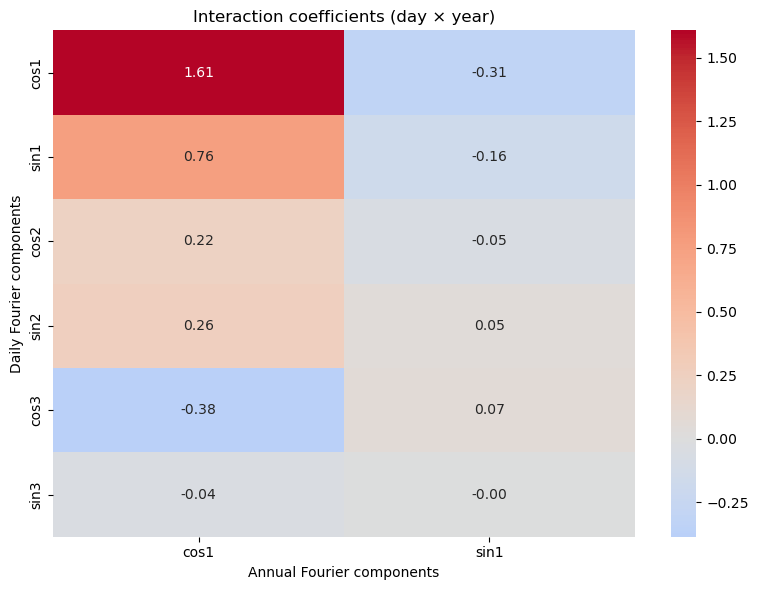

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

n_day  = block_day.shape[1]
n_year = block_year.shape[1]

inter_matrix = np.zeros((n_day, n_year))
k = 0
for i in range(n_day):
    for j in range(n_year):
        inter_matrix[i, j] = coef_inter.iloc[k]
        k += 1

day_labels  = [f"cos{k}" if i % 2 == 0 else f"sin{k}"
               for k in range(1, K_day + 1) for i in range(2)]
year_labels = [f"cos{k}" if i % 2 == 0 else f"sin{k}"
               for k in range(1, K_year + 1) for i in range(2)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    inter_matrix,
    xticklabels=year_labels,
    yticklabels=day_labels,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.xlabel("Annual Fourier components")
plt.ylabel("Daily Fourier components")
plt.title("Interaction coefficients (day × year)")
plt.tight_layout()
plt.show()

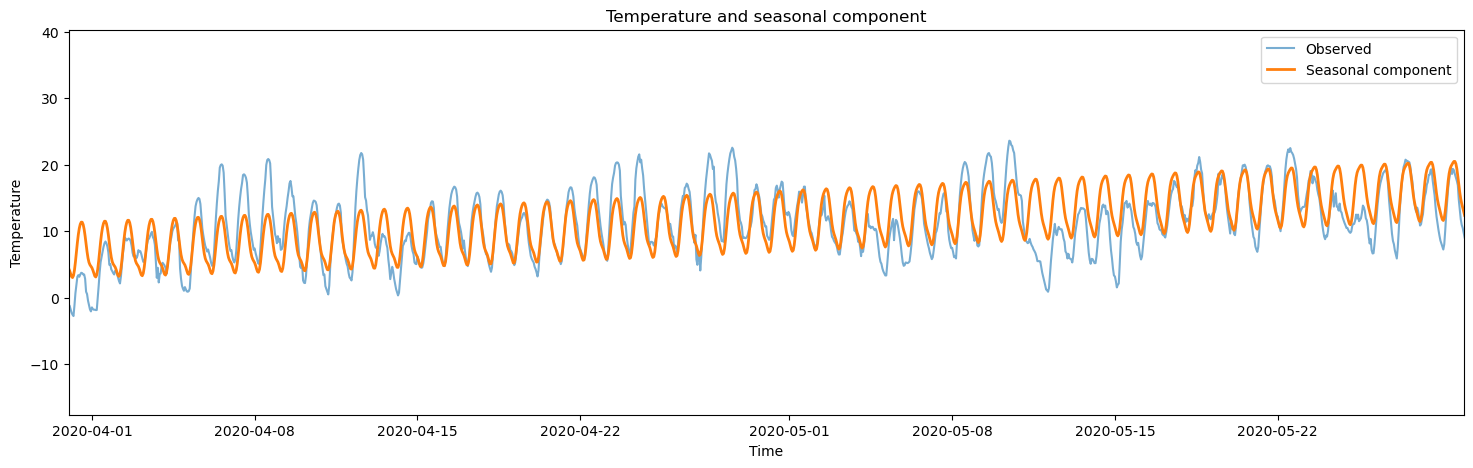

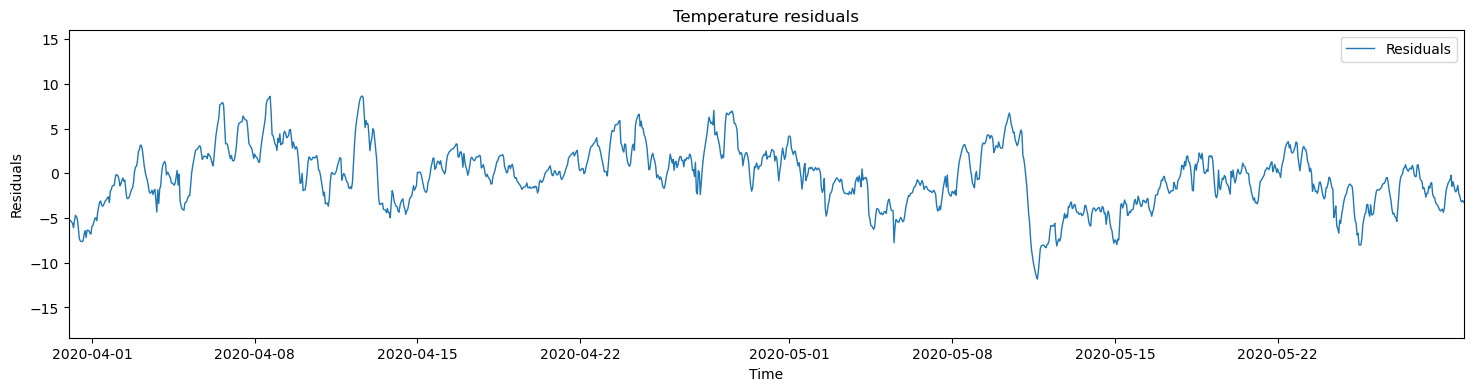

In [ ]:
plt.figure(figsize=(18,5))
plt.plot(temp.index, temp.values, alpha=0.6, label="Observed")
plt.plot(temp.index, temp_fit, linewidth=2, label="Seasonal component")
plt.xlim(temp.index[24*30*3], temp.index[24*30*5])  
plt.legend()
plt.title("Temperature and seasonal component")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

plt.figure(figsize=(18,4))
plt.plot(temp_resid.index, temp_resid.values, linewidth=1, label="Residuals")
plt.legend()
plt.xlim(temp.index[24*30*3], temp.index[24*30*5])  
plt.title("Temperature residuals")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.show()

#### Autocorrelation structure — before and after deseasonalization

The ACF of the raw temperature series shows strong periodicity at lags 24 h and 8760 h. After removing the deterministic seasonal component the ACF decays geometrically, confirming that the residual $r_t = y_t - \hat{y}_t$ is a weakly stationary process amenable to CARMA modelling.

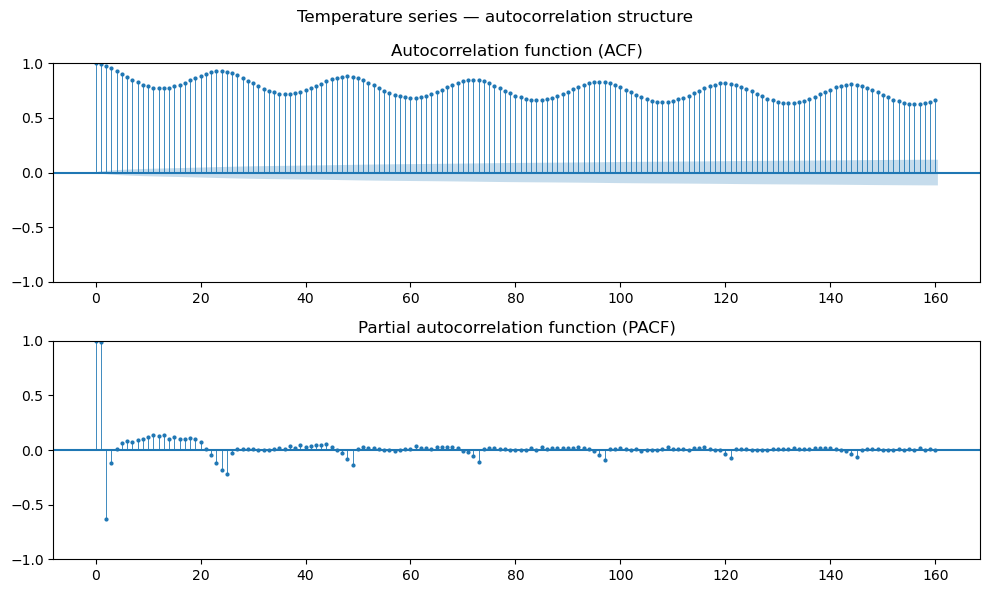

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 6))
fig.suptitle("Temperature series — autocorrelation structure")

plot_acf(temp,  lags=160, ax=axs[0], vlines_kwargs={"linewidth": 0.6}, markersize=2)
axs[0].set_title("Partial autocorrelation function (PACF)")

plot_pacf(temp, lags=160, ax=axs[1], vlines_kwargs={"linewidth": 0.6}, markersize=2)
axs[1].set_title("Partial autocorrelation function (PACF)")

plt.tight_layout()
plt.show()

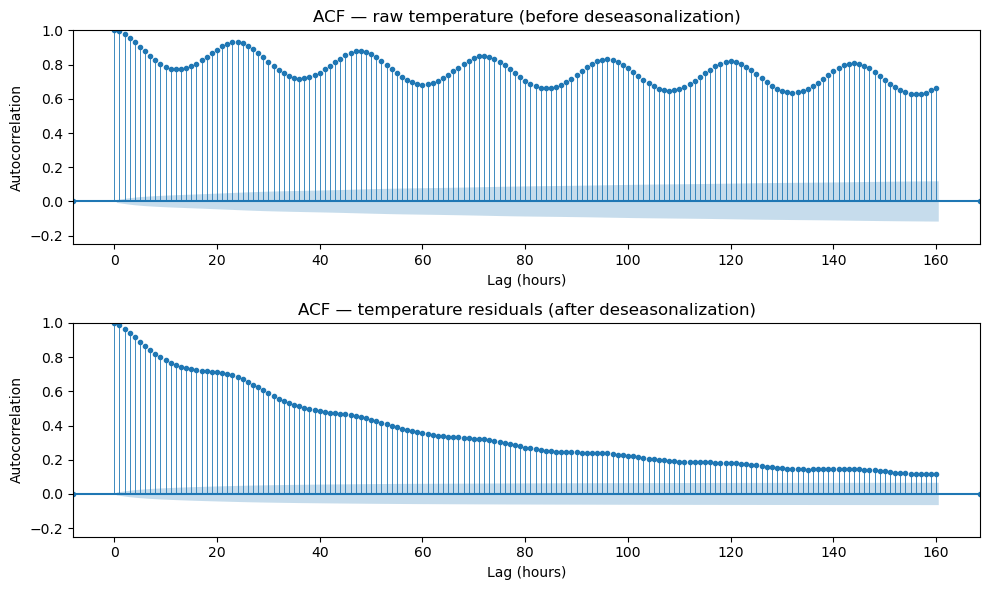

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(temp, lags=160, ax=axs[0],
         vlines_kwargs={"linewidth": 0.6}, marker='o', markersize=3)
axs[0].set_title("ACF — raw temperature (before deseasonalization)")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Lag (hours)")

plot_acf(temp_resid, lags=160, ax=axs[1],
         vlines_kwargs={"linewidth": 0.6}, marker='o', markersize=3)
axs[1].set_title("ACF — temperature residuals (after deseasonalization)")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Lag (hours)")

axs[0].set_ylim(-0.25, 1)
axs[1].set_ylim(-0.25, 1)

plt.tight_layout()
plt.show()

In [46]:
temp_resid.to_frame(name="temp_deseasoned") \
           .rename_axis("datetime") \
           .to_csv("../data/deseasonalised/temp_resid.csv")

In [47]:
import pandas as pd

temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res = temp_resid["temp_deseasoned"].copy()
time_temp = temp_res.index.copy()

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss

### Residual diagnostics — temperature

Assesses stationarity and distributional properties of the deseasonalized temperature residuals $r_t^Y = y_t - \hat{y}_t^{\text{seas}}$. A histogram and normal QQ-plot test for Gaussianity; summary statistics (mean, standard deviation, skewness, excess kurtosis) quantify departures from normality that motivate the NIG distribution in the Lévy fitting step (notebook 06).

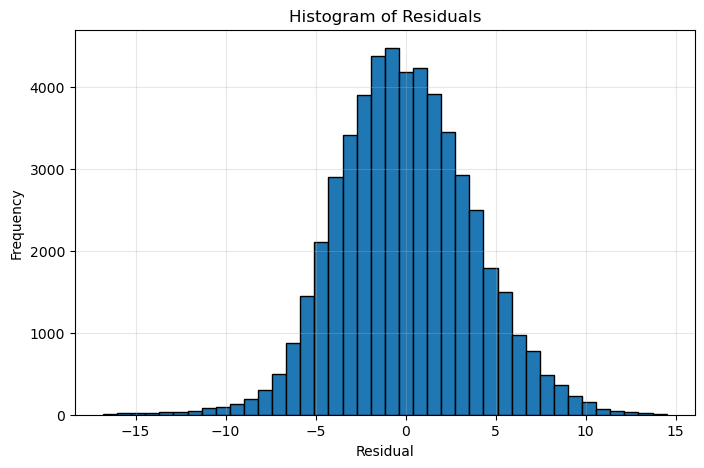

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(temp_resid, bins=40, edgecolor="black")
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

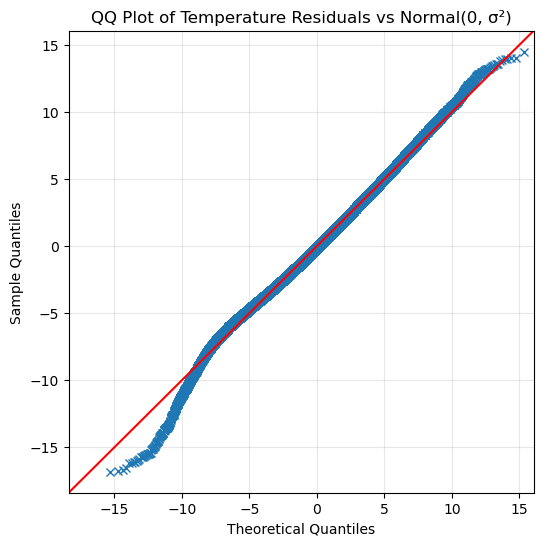

In [ ]:
# ensure Series
temp_series = temp_resid.squeeze()

plt.figure(figsize=(6, 6))
qqplot(temp_series,
       dist=norm,
       loc=0,
       scale=np.std(temp_series),
       line='45',
       marker='x',
       ax=plt.gca())

plt.title("QQ Plot of Temperature Residuals vs Normal(0, σ²)")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
temp_series = temp_resid.squeeze()
summary_stats_temp = pd.DataFrame({
    "Value": [
        temp_series.count(),
        temp_series.mean(),
        temp_series.std(),
        temp_series.min(),
        temp_series.quantile(0.25),
        temp_series.median(),
        temp_series.quantile(0.75),
        temp_series.max(),
        stats.skew(temp_series, bias=False),
        stats.kurtosis(temp_series, fisher=True, bias=False)
    ]
}, index=[
    "Count",
    "Mean",
    "Std",
    "Min",
    "25%",
    "Median",
    "75%",
    "Max",
    "Skewness",
    "Excess Kurtosis"
])

print("Summary Statistics for Temperature Residuals\n")
print(summary_stats_temp.round(4))

Summary Statistics for Temperature Residuals

                      Value
Count            52608.0000
Mean                 0.0000
Std                  3.7241
Min                -16.8168
25%                 -2.5350
Median              -0.1347
75%                  2.4491
Max                 14.4909
Skewness             0.0576
Excess Kurtosis      0.4054


### Out-of-sample diagnostics — temperature seasonality (2026)

Tests whether the Fourier seasonal model fitted on 2020–2025 generalises to unseen 2026 data (January–April). 
RMSE and MAE are compared against in-sample values; a ratio close to 1 indicates no overfitting. 
Systematic patterns in the 2026 residuals (biased mean, inflated ACF, or heavier tails) would signal structural misspecification.

In [49]:
responses_2026 = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": 52.52,
        "longitude": 13.41,
        "hourly": ["temperature_2m"],
        "timezone": "UTC",
        "start_date": "2026-01-01",
        "end_date": "2026-04-22",
    }
)
r26 = responses_2026[0].Hourly()
time_2026 = pd.date_range(
    start=pd.to_datetime(r26.Time(), unit="s", utc=True),
    end=pd.to_datetime(r26.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=r26.Interval()),
    inclusive="left",
)
temp_2026 = (
    pd.Series(r26.Variables(0).ValuesAsNumpy(), index=time_2026, name="temperature_c")
    .sort_index().asfreq("h").interpolate(method="linear")
)
start_str = str(temp_2026.index[0].date())
end_str   = str(temp_2026.index[-1].date())
print(f"2026 temperature: {len(temp_2026)} hourly observations ({start_str} to {end_str})")
print(temp_2026.describe().round(3))

2026 temperature: 2688 hourly observations (2026-01-01 to 2026-04-22)
count    2688.000
mean        3.339
std         6.366
min       -12.850
25%        -1.250
50%         3.100
75%         8.050
max        21.600
Name: temperature_c, dtype: float64


=== Out-of-sample error metrics ===
      train (2020-25)  test (2026)  ratio (test/train)
RMSE           3.7931       4.5468        1.198700e+00
MAE            2.9979       3.6439        1.215500e+00
Std            3.7931       4.3460        1.145800e+00
Mean           0.0000      -1.3389        2.055680e+09


ValueError: Data must be 1-dimensional, got ndarray of shape (52608, 1) instead

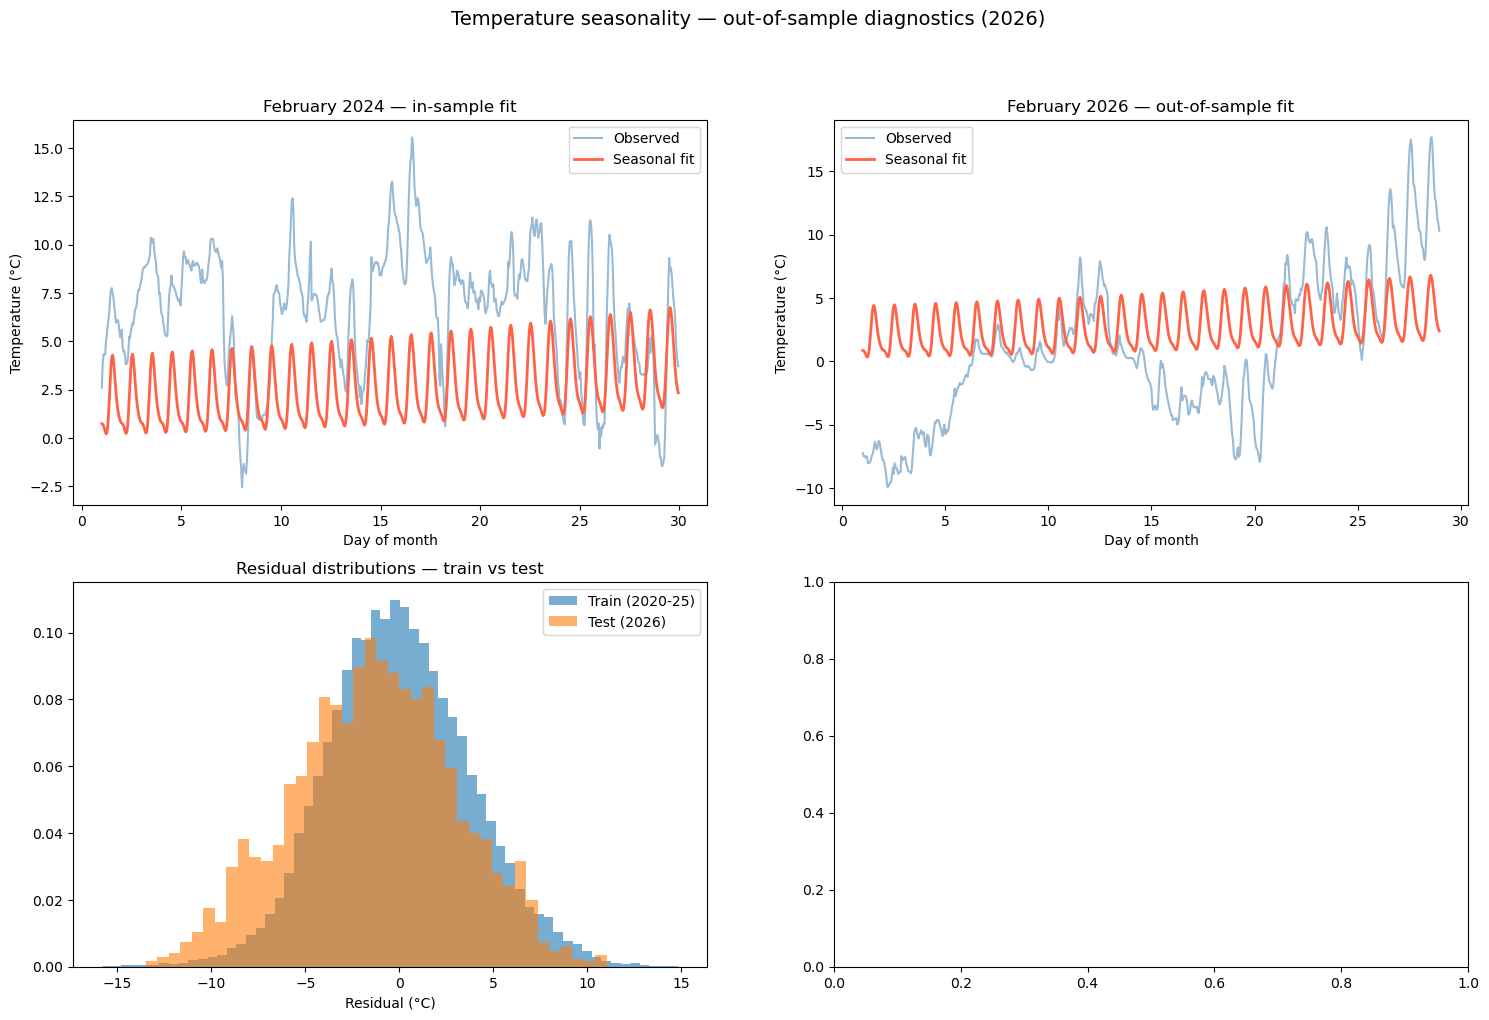

In [50]:
# Build design matrix for 2026 (same time origin and Fourier structure as training)
xt_2026 = ((temp_2026.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

bd26 = fourier_block(xt_2026, P_day,  K_day)
by26 = fourier_block(xt_2026, P_year, K_year)
bi26 = np.column_stack([
    bd26[:, i] * by26[:, j]
    for i in range(bd26.shape[1])
    for j in range(by26.shape[1])
])
Xt26 = np.column_stack([np.ones_like(xt_2026), xt_2026, bd26, by26, bi26])

fit_2026   = Xt26 @ betat
resid_2026 = pd.Series(
    temp_2026.values - fit_2026,
    index=temp_2026.index,
    name="resid_2026",
)

# In-sample Feb 2024 fit (re-use training series and fit)
feb24_mask  = (temp.index.month == 2) & (temp.index.year == 2024)
temp_feb24  = temp[feb24_mask]
xt_feb24    = ((temp_feb24.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
bd24 = fourier_block(xt_feb24, P_day,  K_day)
by24 = fourier_block(xt_feb24, P_year, K_year)
bi24 = np.column_stack([
    bd24[:, i] * by24[:, j]
    for i in range(bd24.shape[1])
    for j in range(by24.shape[1])
])
Xt24     = np.column_stack([np.ones_like(xt_feb24), xt_feb24, bd24, by24, bi24])
fit_feb24 = Xt24 @ betat
resid_feb24 = pd.Series(
    temp_feb24.values - fit_feb24,
    index=temp_feb24.index,
    name="resid_feb24",
)

feb26_mask  = temp_2026.index.month == 2
temp_feb26  = temp_2026[feb26_mask]
fit_feb26   = fit_2026[feb26_mask]
resid_feb26 = resid_2026[feb26_mask]

# Error metrics
def _rmse(e): return float(np.sqrt(np.mean(np.asarray(e)**2)))
def _mae(e):  return float(np.mean(np.abs(np.asarray(e))))

metrics_df = pd.DataFrame({
    "train (2020-25)": {
        "RMSE": _rmse(temp_resid),
        "MAE":  _mae(temp_resid),
        "Std":  float(np.asarray(temp_resid).std()),
        "Mean": float(np.asarray(temp_resid).mean()),
    },
    "test (2026)": {
        "RMSE": _rmse(resid_2026),
        "MAE":  _mae(resid_2026),
        "Std":  float(resid_2026.std()),
        "Mean": float(resid_2026.mean()),
    },
})
metrics_df["ratio (test/train)"] = (
    metrics_df["test (2026)"].abs() / metrics_df["train (2020-25)"].abs()
)
print("=== Out-of-sample error metrics ===")
print(metrics_df.round(4))

# Plots — 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Temperature seasonality — out-of-sample diagnostics (2026)", fontsize=14)

# Shared day-of-month x-axis for Feb comparison
days24 = temp_feb24.index.day + (temp_feb24.index.hour / 24)
days26 = temp_feb26.index.day + (temp_feb26.index.hour / 24)

# 1. Feb 2024 — in-sample fit
axes[0, 0].plot(days24, temp_feb24.values, alpha=0.55, label="Observed", color="steelblue")
axes[0, 0].plot(days24, fit_feb24, linewidth=2, label="Seasonal fit", color="tomato")
axes[0, 0].set_title("February 2024 — in-sample fit", fontsize=12)
axes[0, 0].set_xlabel("Day of month")
axes[0, 0].set_ylabel("Temperature (\u00b0C)")
axes[0, 0].legend()

# 2. Feb 2026 — out-of-sample fit
axes[0, 1].plot(days26, temp_feb26.values, alpha=0.55, label="Observed", color="steelblue")
axes[0, 1].plot(days26, fit_feb26, linewidth=2, label="Seasonal fit", color="tomato")
axes[0, 1].set_title("February 2026 — out-of-sample fit", fontsize=12)
axes[0, 1].set_xlabel("Day of month")
axes[0, 1].set_ylabel("Temperature (\u00b0C)")
axes[0, 1].legend()

# 3. Residual distributions: train vs test
axes[1, 0].hist(np.asarray(temp_resid), bins=60, alpha=0.6, density=True, label="Train (2020-25)")
axes[1, 0].hist(resid_2026.values,      bins=40, alpha=0.6, density=True, label="Test (2026)")
axes[1, 0].set_title("Residual distributions — train vs test", fontsize=12)
axes[1, 0].legend()
axes[1, 0].set_xlabel("Residual (\u00b0C)")

# 4. RMSE by month: test 2026 vs training average (same months)
tr_idx  = pd.to_datetime(temp_resid.index)
tr_vals = np.asarray(temp_resid)
rmse_train_by_month = (
    pd.Series(tr_vals, index=tr_idx)
    .groupby(tr_idx.month)
    .apply(_rmse)
)
rmse_2026_by_month = resid_2026.groupby(resid_2026.index.month).apply(_rmse)
common_months = rmse_2026_by_month.index
axes[1, 1].bar(common_months - 0.2,
               rmse_2026_by_month.values, width=0.35,
               label="Test 2026", color="steelblue")
axes[1, 1].bar(rmse_train_by_month.reindex(common_months).index + 0.2,
               rmse_train_by_month.reindex(common_months).values, width=0.35,
               label="Train avg (same months)", color="orange", alpha=0.8)
axes[1, 1].set_title("RMSE by month", fontsize=12)
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("RMSE (\u00b0C)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Save raw temperature, seasonal fit, and residuals for notebook 05
pd.DataFrame({
    "temp_raw":   temp_2026.values,
    "temp_seas":  fit_2026,
    "temp_resid": resid_2026.values,
}, index=temp_2026.index).to_csv("../data/deseasonalised/temp_2026_full.csv")
print("Saved temp_2026_full.csv")


### Deseasonalise prices : Paraschiv's method

The spot price is decomposed into a deterministic seasonal component and a stochastic component:

$$
P_t = f_t + X_t
$$

where $f_t$ is the deterministic seasonality and $X_t$ the deseasonalized residual.

The deterministic component can be written as a trend plus seasonality:

$$
f_t = f_t^{trend} + f_t^{season}
$$

with linear trend

$$
f_t^{trend} = a^{trend} + b^{trend} t
$$

In the empirical implementation, the seasonal shape is constructed multiplicatively as:

$$
s_t = \bar P \, f2y_t \, f2d_t
$$

and the deseasonalized price is:

$$
X_t = P_t - s_t
$$

### Factor-to-year

Let $S_{day}(d)$ be the average spot price of day $d$. The factor-to-year is defined by:

$$
f2y_d
=
\frac{S_{day}(d)}
{\frac{1}{K(d)} \sum_{k \in year(d)} S_{day}(k)}
$$

where $K(d)$ is the number of days in the year containing day $d$.

It is modeled by the regression:

$$
f2y_d
=
\alpha_0
+
\sum_{i=1}^{6} b_i D_{d,i}
+
\sum_{i=1}^{12} c_i M_{d,i}
+
\sum_{i=1}^{3} d_i \, CDD_{d,i}
+
\sum_{i=1}^{3} e_i \, HDD_{d,i}
+
\varepsilon_d
$$

with

$$
CDD = \max(T - 18.3, 0)
$$

$$
HDD = \max(18.3 - T, 0)
$$

The daily factor is then converted to hourly frequency by:

$$
f2y_t = f2y_d \qquad \text{for all } t \in d
$$

### Factor-to-day

Let $S_{hour}(t)$ be the hourly spot price. The factor-to-day is defined by:

$$
f2d_t
=
\frac{S_{hour}(t)}
{\frac{1}{24}\sum_{k \in day(t)} S_{hour}(k)}
$$

Days are partitioned into 20 profile classes. For each class $c$, the intraday profile is estimated by:

$$
f2d_t
=
a_0^{(c)}
+
\sum_{i=1}^{23} b_i^{(c)} H_{t,i}
+
\varepsilon_t,
\qquad t \in c
$$

where $H_{t,i}$ are hour-of-day dummies.

### Final seasonal shape

The relative hourly seasonal weight is:

$$
sw_t = f2y_t \, f2d_t
$$

The deterministic seasonal component is then:

$$
s_t = \bar P \, sw_t = \bar P \, f2y_t \, f2d_t
$$

Finally, the deseasonalized price is:

$$
X_t = P_t - s_t
$$

In [ ]:
prices_df = pd.read_csv("../data/raw/prices.csv", index_col=0)


In [ ]:
print(prices_df.head())

                           price_eur_mwh
datetime                                
2023-01-01 00:00:00+00:00          -1.07
2023-01-01 01:00:00+00:00          -1.47
2023-01-01 02:00:00+00:00          -5.08
2023-01-01 03:00:00+00:00          -4.49
2023-01-01 04:00:00+00:00          -5.40


In [ ]:
prices_df.index = pd.to_datetime(prices_df.index)
prices_df = prices_df.sort_index()


### Deseasonalization — log-price (Paraschiv multiplicative decomposition)

Applies the **log-price transformation** $\tilde{S}_t = \log(S_t + \delta)$ with shift $\delta = 1000$ EUR/MWh to map all prices to a positive domain. The seasonal component is then factored as

$$\hat{s}_t = \bar{p}\cdot F2D_t \cdot F2Y_t,$$

where $\bar{p}$ is the sample mean log-price, $F2D_t$ is the intra-day factor estimated from 20 profile classes (weekday/weekend $\times$ season), and $F2Y_t$ is the annual factor estimated by OLS with Fourier harmonics and HDD/CDD regressors.

The deseasonalized residual $r_t^X = \tilde{S}_t - \hat{s}_t$ is the input to ARMA order selection (notebook 03) and CARMA fitting (notebooks 05–07).

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# Log-price transformation
# delta_shift = 1000 EUR/MWh ensures all arguments are positive
# ============================================================
delta_shift = 1000.0

price_raw = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")
price = np.log(price_raw + delta_shift)

print("Log-price stats:")
print(price.describe())
print(f"\nMin raw price: {price_raw.min():.2f} EUR/MWh  =>  log({price_raw.min() + delta_shift:.1f}) = {np.log(price_raw.min() + delta_shift):.6f}")

# ============================================================
# Factor-to-day (F2D)
# f2d_t = price_t / daily_mean(price)  for each hour t
# Estimated separately for each of the 20 profile classes
# (weekday/weekend × season), using hour-of-day dummies.
# ============================================================
day_mean = price.resample("D").mean()
day_mean_per_hour = day_mean.reindex(price.index.floor("D")).to_numpy(dtype=float)
f2d = price.to_numpy(dtype=float) / day_mean_per_hour

idx   = price.index
dow   = idx.dayofweek
month = idx.month

# Assign each hour to one of 20 profile classes:
# weekday months 1-12 → classes 1-12; Saturday/Sunday × 4 seasons → classes 13-20
profile_class = np.zeros(len(idx), dtype=int)
for i in range(len(idx)):
    m = month[i]
    d = dow[i]
    if d <= 4:
        profile_class[i] = m
    elif d == 5:
        if m in [1, 2, 12]:   profile_class[i] = 13
        elif m in [3, 4, 5]:  profile_class[i] = 14
        elif m in [6, 7, 8]:  profile_class[i] = 15
        else:                  profile_class[i] = 16
    elif d == 6:
        if m in [1, 2, 12]:   profile_class[i] = 17
        elif m in [3, 4, 5]:  profile_class[i] = 18
        elif m in [6, 7, 8]:  profile_class[i] = 19
        else:                  profile_class[i] = 20

hour_dummies = pd.get_dummies(idx.hour, drop_first=True).astype(float)
X_base = np.column_stack([np.ones(len(idx)), hour_dummies.to_numpy()])

f2d_hat    = np.zeros(len(idx), dtype=float)
f2d_coeffs_by_class = {}
class_ids  = np.unique(profile_class)

for class_id in class_ids:
    mask        = (profile_class == class_id)
    X_class     = X_base[mask]
    price_class = price[mask].to_numpy()
    coeffs, *_  = np.linalg.lstsq(X_class, price_class, rcond=None)
    predicted   = X_class @ coeffs
    mean_shape  = np.mean(predicted)
    f2d_hat[mask] = predicted / mean_shape if mean_shape != 0 else 1.0
    f2d_coeffs_by_class[class_id] = (coeffs, mean_shape)

averageprice = price.mean()

Log-price stats:
count    26281.000000
mean         6.990761
std          0.046718
min          6.214608
25%          6.970711
50%          6.994061
75%          7.014886
max          7.568524
Name: price_eur_mwh, dtype: float64

Min raw price: -500.00 EUR/MWh  =>  log(500.0) = 6.214608


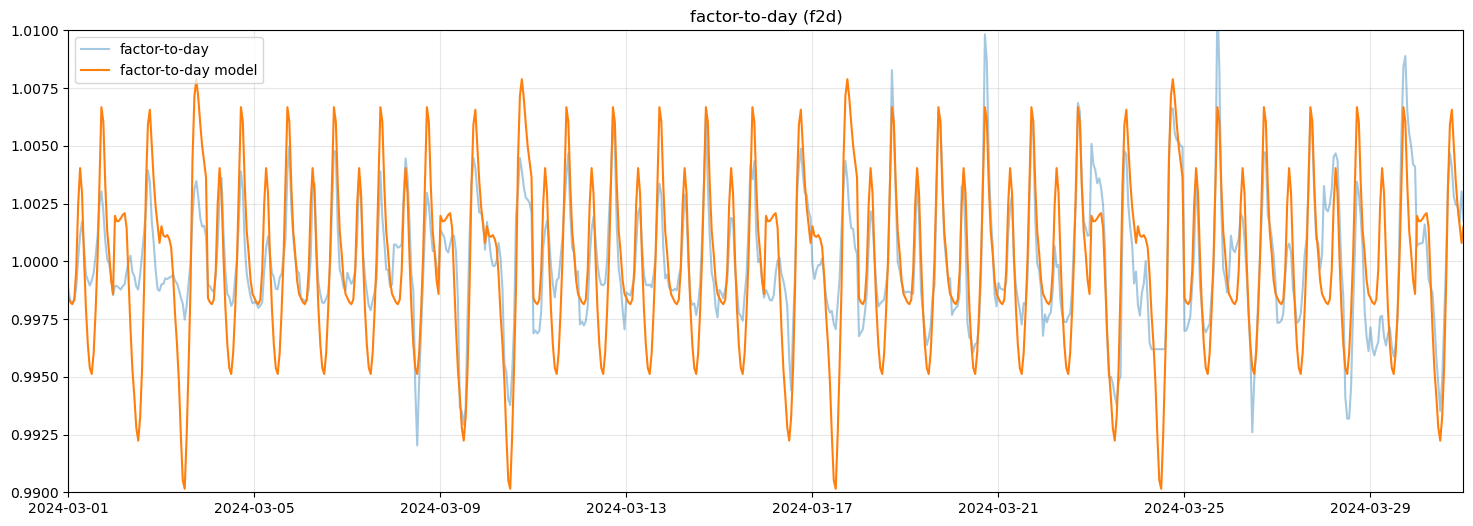

In [ ]:
plt.figure(figsize=(18,6))
plt.plot(idx, f2d, alpha=0.4, label="factor-to-day")
plt.plot(idx, f2d_hat, label="factor-to-day model")

start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(0.99,1.01)
plt.title("factor-to-day (f2d)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Factor-to-year (F2Y) estimation

Estimates the annual seasonal factor $F2Y_d$ by regressing the daily mean log-price on weekday dummies, month dummies (with August split into early/late), and heating/cooling degree-day regressors (base 15 °C):

$$F2Y_d = \alpha_0 + \sum_{i=1}^{6}\beta_i D_{d,i}^{\text{dow}} + \sum_{m\neq 8}\gamma_m \mathbf{1}_{\{d \in m\}} + \delta_1 \text{HDD}_d + \delta_2 \text{CDD}_d + \varepsilon_d.$$

The fitted daily factor is broadcast to hourly frequency by assigning each hour the value of its calendar day.

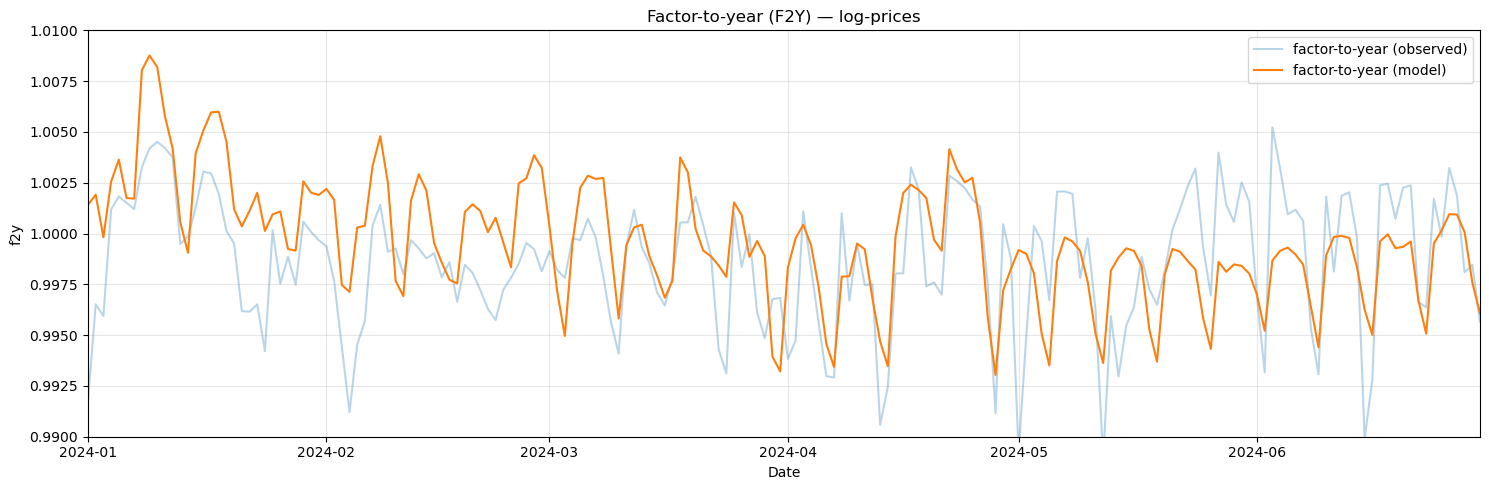

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Same log-price transformation (delta_shift = 1000 EUR/MWh)
delta_shift = 1000.0
price_raw = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")
price = np.log(price_raw + delta_shift)

S_day    = price.resample("D").mean()
temp_day = temp.resample("D").mean()

combined_base = (
    pd.concat([S_day.rename("price_eur_mwh"), temp_day.rename("temperature_c")],
              axis=1, join="inner")
    .dropna()
)
S_day    = combined_base["price_eur_mwh"]
temp_day = combined_base["temperature_c"]

# Factor-to-year: ratio of daily average price to annual average price
yearly_mean = S_day.groupby(S_day.index.year).transform("mean")
y = (S_day / yearly_mean).dropna()

X = pd.DataFrame(index=y.index)

# Weekday dummies (Mon–Sat; Sunday is the reference)
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
for d, lbl in enumerate(day_labels):
    X[lbl] = (X.index.dayofweek == d).astype(int)

# Month dummies (reference = August, split into two halves below)
for m in range(2, 13):
    if m != 8:
        X[f"Month_{m}"] = (X.index.month == m).astype(int)

# August split to capture early/late-summer effect
X["Aug_early"] = ((X.index.month == 8) & (X.index.day <= 15)).astype(int)
X["Aug_late"]  = ((X.index.month == 8) & (X.index.day  > 15)).astype(int)

# Heating and cooling degree days (base temperature 15 °C)
t = temp_day.reindex(y.index)
X["HDD"] = (15 - t).clip(lower=0)
X["CDD"] = (t - 15).clip(lower=0)

X = sm.add_constant(X)

df_model = pd.concat([y.rename("y"), X], axis=1).dropna()
y2 = df_model["y"]
X2 = df_model.drop(columns=["y"])

model_f2y  = sm.OLS(y2, X2).fit()
f2y_d_hat  = model_f2y.fittedvalues

plt.figure(figsize=(15, 5))
plt.plot(y2.index, y2, label="factor-to-year (observed)", alpha=0.3)
plt.plot(f2y_d_hat.index, f2y_d_hat, label="factor-to-year (model)")
plt.legend()

start_zoom = "2024-01-01"
end_zoom   = "2024-06-30"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(0.99, 1.01)
plt.title("Factor-to-year (F2Y) — log-prices")
plt.xlabel("Date")
plt.ylabel("f2y")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Final seasonal component and deseasonalized log-price residuals

Combines the estimated factors into the full multiplicative seasonal component:
$$\hat{s}_t = \bar{p}\cdot F2D_t \cdot F2Y_t.$$
The deseasonalized residual $r_t^X = \tilde{S}_t - \hat{s}_t$ is saved to `price_resid.csv` and passed to notebook 03 for ARMA order selection.

In [ ]:
# Broadcast daily f2y to hourly: each hour inherits the value of its calendar day
f2y_t_hat = f2y_d_hat.reindex(price.index.floor("D")).to_numpy()
f2y_t_hat = pd.Series(f2y_t_hat, index=price.index, name="f2y_t_hat")

# Composite seasonal weight: sw_t = f2y_t * f2d_t
sw_t = f2y_t_hat * f2d_hat
yearly_avg = np.mean(price.values)

# Deterministic seasonal component: s_t = avg_log_price * sw_t
price_fit = pd.Series(sw_t * yearly_avg, index=price.index)

# Deseasonalized log-price residual
price_resid = (price - price_fit).rename("price_deseasoned")

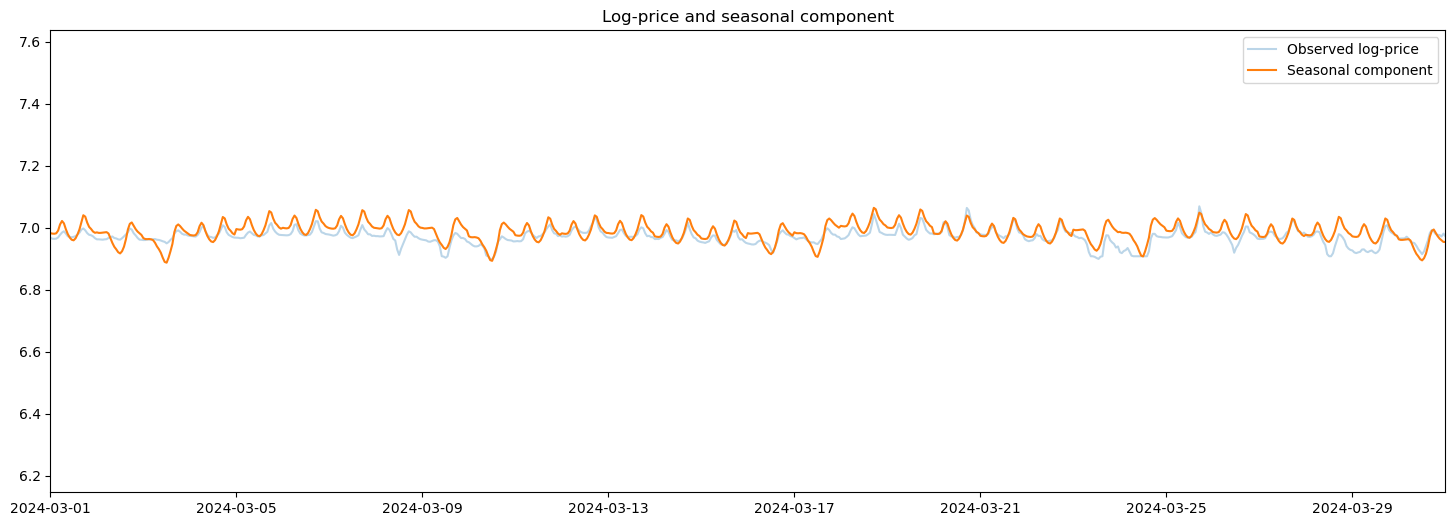

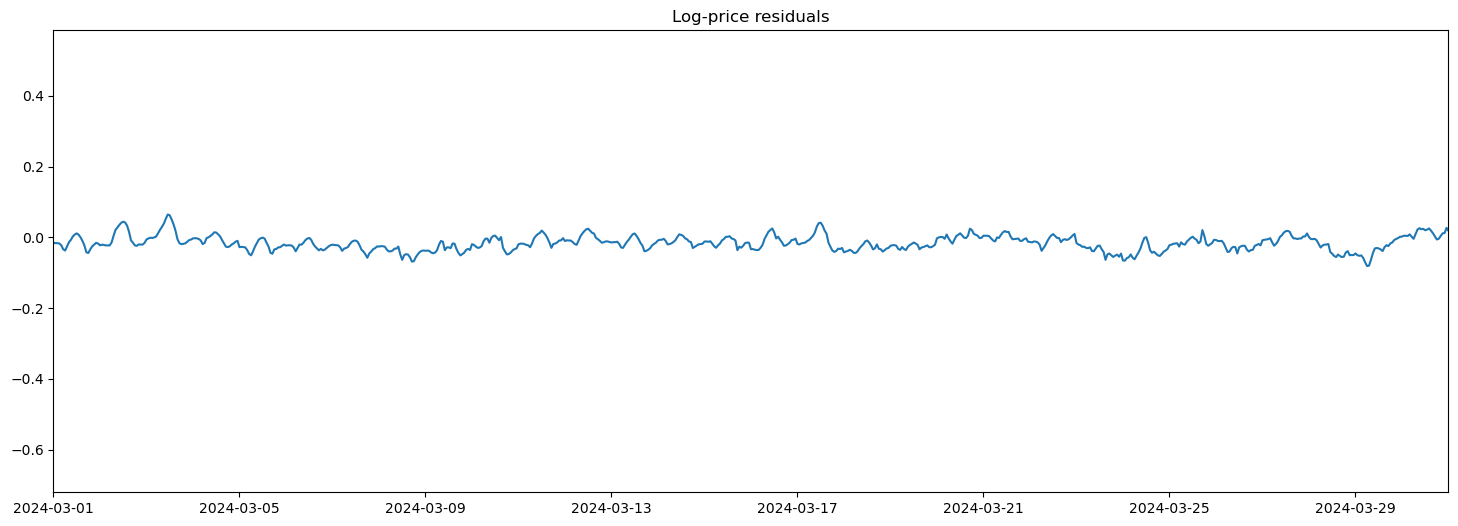

In [ ]:
plt.figure(figsize=(18, 6))
plt.plot(price.index, price, alpha=0.3, label="Observed log-price")
plt.plot(price.index, price_fit, label="Seasonal component")
start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("Log-price and seasonal component")
plt.legend()

plt.figure(figsize=(18, 6))
plt.plot(idx, price_resid)
start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("Log-price residuals")
plt.show()

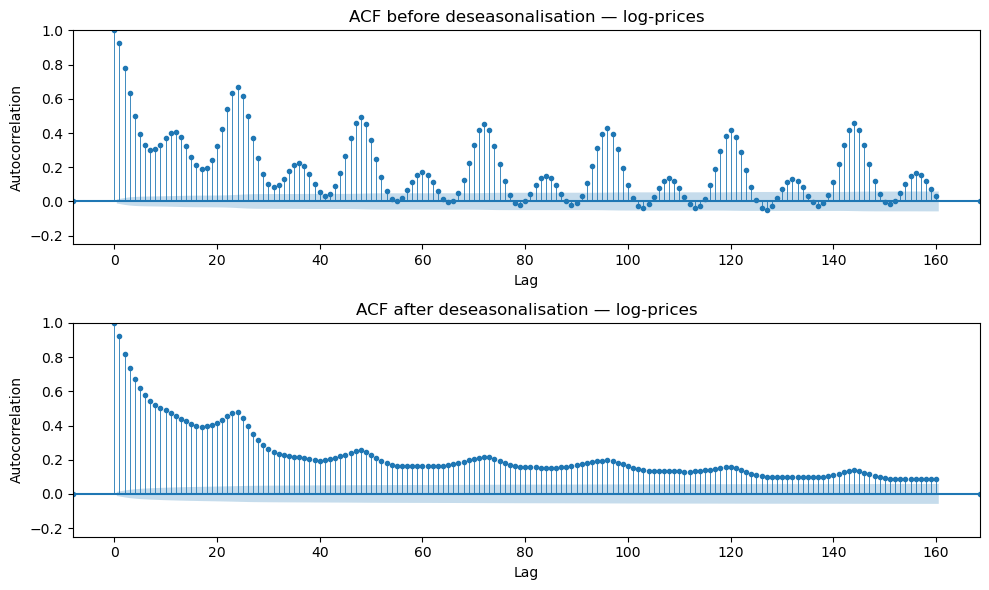

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(price, lags=160, ax=axs[0],
         vlines_kwargs={"linewidth":0.6},
         marker='o', markersize=3)
axs[0].set_title("ACF before deseasonalisation — log-prices")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Lag")

plot_acf(price_resid, lags=160, ax=axs[1],
         vlines_kwargs={"linewidth":0.6},
         marker='o', markersize=3)
axs[1].set_title("ACF after deseasonalisation — log-prices")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Lag")

axs[0].set_ylim(-0.25, 1)
axs[1].set_ylim(-0.25, 1)

plt.tight_layout()
plt.show()

In [ ]:
price_resid.to_frame(name="price_deseasoned") \
           .rename_axis("datetime") \
           .to_csv("../data/deseasonalised/price_resid.csv")

In [ ]:
import pandas as pd

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_res = price_resid["price_deseasoned"].copy()
time_price = price_res.index.copy()

### Residual diagnostics — log-prices



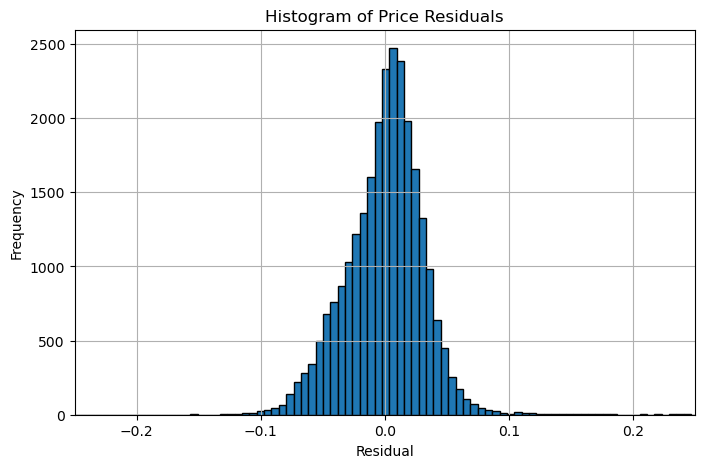

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(price_resid, bins=200, edgecolor="black")
plt.xlim(-0.25, 0.25)
plt.title("Histogram of Price Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=1)
plt.show()

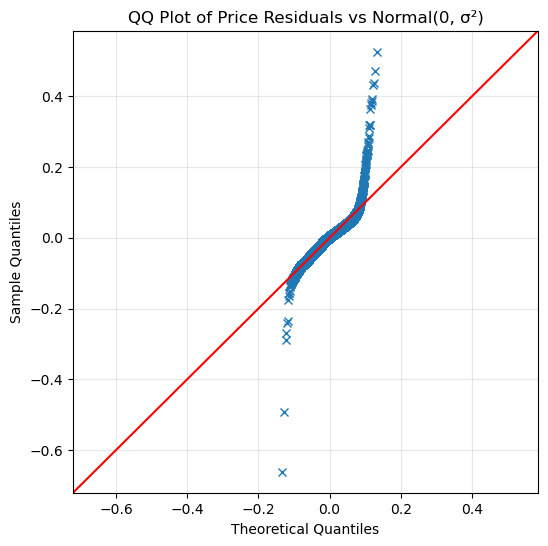

In [ ]:
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
import numpy as np
import matplotlib.pyplot as plt

# ensure Series
price_series = price_resid.squeeze()
 
 
plt.figure(figsize=(6, 6))
qqplot(price_series,
       dist=norm,
       loc=0,
       scale=np.std(price_series),
       line='45',
       marker='x',
       ax=plt.gca())

plt.title("QQ Plot of Price Residuals vs Normal(0, σ²)")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
price_series = price_resid.squeeze()
summary_stats_price = pd.DataFrame({
    "Value": [
        price_series.count(),
        price_series.mean(),
        price_series.std(),
        price_series.min(),
        price_series.quantile(0.25),
        price_series.median(),
        price_series.quantile(0.75),
        price_series.max(),
        stats.skew(price_series, bias=False),
        stats.kurtosis(price_series, fisher=True, bias=False)
    ]
}, index=[
    "Count",
    "Mean",
    "Std",
    "Min",
    "25%",
    "Median",
    "75%",
    "Max",
    "Skewness",
    "Excess Kurtosis"
])

print(summary_stats_price.round(4))

                      Value
Count            26281.0000
Mean                 0.0000
Std                  0.0336
Min                 -0.6614
25%                 -0.0189
Median               0.0026
75%                  0.0193
Max                  0.5261
Skewness             0.5699
Excess Kurtosis     21.1093


### Out-of-sample diagnostics — price seasonality (2026)

Applies the fitted F2D and F2Y models (estimated on 2023–2025) to 2026 log-prices (January–April). The F2Y prediction uses 2026 daily temperatures (HDD/CDD regressors) fetched above. RMSE and MAE ratios close to 1 indicate the seasonal decomposition generalises well out of sample.

In [34]:
prices_raw_2026 = client.query_day_ahead_prices(
    ZONE,
    start=pd.Timestamp("2026-01-01", tz="UTC"),
    end=pd.Timestamp("2026-04-23", tz="UTC"),
)
price_raw_2026 = (
    prices_raw_2026.to_frame(name="price_eur_mwh")["price_eur_mwh"]
    .sort_index().tz_convert("UTC").asfreq("h").interpolate(method="linear")
)
price_2026 = np.log(price_raw_2026 + delta_shift)
start_str = str(price_2026.index[0].date())
end_str   = str(price_2026.index[-1].date())
print(f"2026 log-prices: {len(price_2026)} hourly observations ({start_str} to {end_str})")
print(price_2026.describe().round(4))

2026 log-prices: 2689 hourly observations (2026-01-01 to 2026-04-23)
count    2689.0000
mean        7.0022
std         0.0456
min         6.7605
25%         6.9884
50%         7.0060
75%         7.0264
max         7.1936
Name: price_eur_mwh, dtype: float64


NaN in resid_price_26: 1
=== Out-of-sample error metrics — log-price ===
      train (2023-25)  test (2026)  ratio (test/train)
RMSE           0.0336       0.0383              1.1393
MAE            0.0242       0.0295              1.2167
Std            0.0336       0.0382              1.1373
Mean           0.0000      -0.0023            112.3566


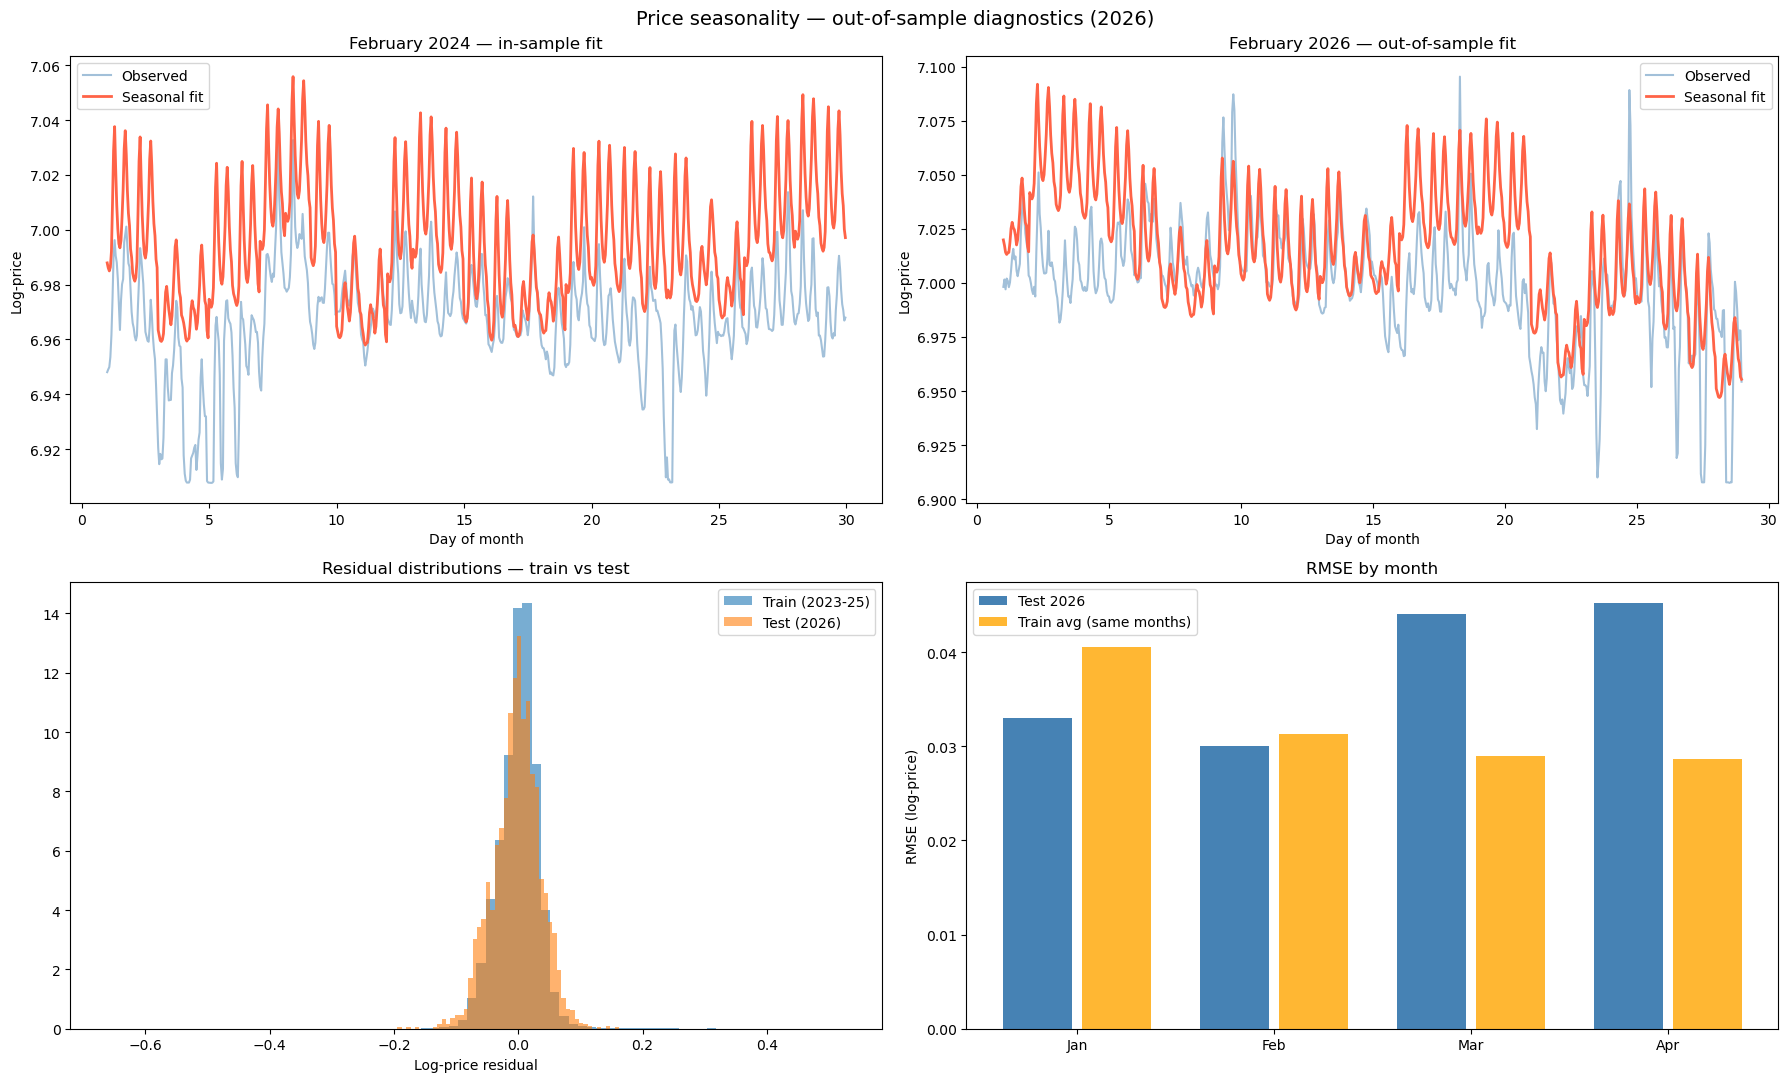

Saved price_2026_full.csv


In [35]:
import statsmodels.api as sm
import calendar

# F2D for 2026 — assign profile classes, apply stored per-class coefficients
idx_26   = price_2026.index
dow_26   = idx_26.dayofweek
month_26 = idx_26.month

profile_class_26 = np.zeros(len(idx_26), dtype=int)
for i in range(len(idx_26)):
    m, d = month_26[i], dow_26[i]
    if d <= 4:
        profile_class_26[i] = m
    elif d == 5:
        profile_class_26[i] = 13 if m in [1,2,12] else 14 if m in [3,4,5] else 15 if m in [6,7,8] else 16
    else:
        profile_class_26[i] = 17 if m in [1,2,12] else 18 if m in [3,4,5] else 19 if m in [6,7,8] else 20

hour_dummies_26 = pd.get_dummies(idx_26.hour, drop_first=True).astype(float)
X_base_26 = np.column_stack([np.ones(len(idx_26)), hour_dummies_26.to_numpy()])

f2d_hat_26 = np.zeros(len(idx_26), dtype=float)
for cid in np.unique(profile_class_26):
    mask = profile_class_26 == cid
    if cid in f2d_coeffs_by_class:
        c26, ms26 = f2d_coeffs_by_class[cid]
        pred = X_base_26[mask] @ c26
        f2d_hat_26[mask] = pred / ms26 if ms26 != 0 else 1.0
    else:
        f2d_hat_26[mask] = 1.0

# F2Y for 2026 — build daily regressors using 2026 temperatures, predict with model_f2y
temp_day_26  = temp_2026.resample("D").mean()
price_day_26 = price_2026.resample("D").mean()

X26 = pd.DataFrame(index=price_day_26.index)
for d26, lbl in enumerate(["Mon","Tue","Wed","Thu","Fri","Sat"]):
    X26[lbl] = (X26.index.dayofweek == d26).astype(int)
for m26 in range(2, 13):
    if m26 != 8:
        X26[f"Month_{m26}"] = (X26.index.month == m26).astype(int)
X26["Aug_early"] = ((X26.index.month == 8) & (X26.index.day <= 15)).astype(int)
X26["Aug_late"]  = ((X26.index.month == 8) & (X26.index.day  > 15)).astype(int)
t26 = temp_day_26.reindex(X26.index)
X26["HDD"] = (15 - t26).clip(lower=0)
X26["CDD"] = (t26 - 15).clip(lower=0)
X26 = sm.add_constant(X26)

# Align columns exactly with training model before predicting
X26 = X26.reindex(columns=model_f2y.model.exog_names, fill_value=0)

f2y_d_26 = model_f2y.predict(X26)

# Broadcast daily F2Y to hourly by matching on calendar day
daily_index_26 = price_2026.index.normalize()          # tz-aware midnight
f2y_t_26 = f2y_d_26.reindex(daily_index_26).values    # aligned array, same length

price_fit_26   = pd.Series(f2y_t_26 * f2d_hat_26 * yearly_avg, index=price_2026.index)
resid_price_26 = (price_2026 - price_fit_26).dropna()

print(f"NaN in resid_price_26: {(price_2026 - price_fit_26).isna().sum()}")

# Error metrics (nanmean for robustness)
def _rmse(e): return float(np.sqrt(np.nanmean(np.asarray(e, dtype=float)**2)))
def _mae(e):  return float(np.nanmean(np.abs(np.asarray(e, dtype=float))))

metrics_df = pd.DataFrame({
    "train (2023-25)": {
        "RMSE": _rmse(price_res),
        "MAE":  _mae(price_res),
        "Std":  float(price_res.std()),
        "Mean": float(price_res.mean()),
    },
    "test (2026)": {
        "RMSE": _rmse(resid_price_26),
        "MAE":  _mae(resid_price_26),
        "Std":  float(resid_price_26.std()),
        "Mean": float(resid_price_26.mean()),
    },
})
metrics_df["ratio (test/train)"] = (
    metrics_df["test (2026)"].abs() / metrics_df["train (2023-25)"].abs()
)
print("=== Out-of-sample error metrics — log-price ===")
print(metrics_df.round(4))

# Plots — 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Price seasonality — out-of-sample diagnostics (2026)", fontsize=14)

# Feb 2024 in-sample
feb24_p_mask = (price.index.month == 2) & (price.index.year == 2024)
price_feb24  = price[feb24_p_mask]
fit_feb24_p  = price_fit[feb24_p_mask]
days24p = price_feb24.index.day + price_feb24.index.hour / 24

# Feb 2026 out-of-sample
feb26_p_mask = price_2026.index.month == 2
price_feb26  = price_2026[feb26_p_mask]
fit_feb26_p  = price_fit_26[feb26_p_mask]
days26p = price_feb26.index.day + price_feb26.index.hour / 24

axes[0, 0].plot(days24p, price_feb24.values, alpha=0.5, label="Observed", color="steelblue")
axes[0, 0].plot(days24p, fit_feb24_p.values, linewidth=2,  label="Seasonal fit", color="tomato")
axes[0, 0].set_title("February 2024 — in-sample fit", fontsize=12)
axes[0, 0].set_xlabel("Day of month")
axes[0, 0].set_ylabel("Log-price")
axes[0, 0].legend()

axes[0, 1].plot(days26p, price_feb26.values, alpha=0.5, label="Observed", color="steelblue")
axes[0, 1].plot(days26p, fit_feb26_p.values, linewidth=2,  label="Seasonal fit", color="tomato")
axes[0, 1].set_title("February 2026 — out-of-sample fit", fontsize=12)
axes[0, 1].set_xlabel("Day of month")
axes[0, 1].set_ylabel("Log-price")
axes[0, 1].legend()

axes[1, 0].hist(price_res.values,      bins=80, alpha=0.6, density=True, label="Train (2023-25)")
axes[1, 0].hist(resid_price_26.values, bins=50, alpha=0.6, density=True, label="Test (2026)")
axes[1, 0].set_title("Residual distributions — train vs test", fontsize=12)
axes[1, 0].legend()
axes[1, 0].set_xlabel("Log-price residual")

# RMSE by month with correct x-ticks
tr_idx_p = pd.to_datetime(price_res.index)
rmse_train_by_month_p = (
    pd.Series(price_res.values, index=tr_idx_p)
    .groupby(tr_idx_p.month)
    .apply(_rmse)
)
rmse_26_by_month_p = resid_price_26.groupby(resid_price_26.index.month).apply(_rmse)
common_m = rmse_26_by_month_p.index
axes[1, 1].bar(common_m - 0.2,
               rmse_26_by_month_p.values, width=0.35,
               label="Test 2026", color="steelblue")
axes[1, 1].bar(rmse_train_by_month_p.reindex(common_m).index + 0.2,
               rmse_train_by_month_p.reindex(common_m).values, width=0.35,
               label="Train avg (same months)", color="orange", alpha=0.8)
axes[1, 1].set_xticks(common_m)
axes[1, 1].set_xticklabels([calendar.month_abbr[m] for m in common_m])
axes[1, 1].set_title("RMSE by month", fontsize=12)
axes[1, 1].set_ylabel("RMSE (log-price)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Save raw log-price, seasonal fit, and residuals for notebook 05
pd.DataFrame({
    "price_raw":   price_2026.values,
    "price_seas":  price_fit_26.values,
    "price_resid": (price_2026 - price_fit_26).values,
}, index=price_2026.index).to_csv("../data/deseasonalised/price_2026_full.csv")
print("Saved price_2026_full.csv")


In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

# Temperature seasonal component (Fourier fit) as a Series
temp_seasonal = pd.Series(temp_fit, index=temp.index, name="temp_seasonal")


# Restrict to the intersection where both series are defined
log_price_seasonal = price_fit.rename("log_price_seasonal")
common_index = temp_seasonal.index.intersection(log_price_seasonal.index)

seasonalities = pd.DataFrame({
    "temp_seasonal": temp_seasonal.loc[common_index],
    "log_price_seasonal": log_price_seasonal.loc[common_index],
}, index=common_index)
seasonalities.index.name = "datetime"

out_path = Path("../data/deseasonalised/seasonalities.csv")
seasonalities.to_csv(out_path)
print(f"Saved {len(seasonalities):,} rows to {out_path}")
print(seasonalities.head())


Saved 26,281 rows to ..\data\deseasonalised\seasonalities.csv
                           temp_seasonal  log_price_seasonal
datetime                                                    
2023-01-01 00:00:00+00:00       1.316022            6.933008
2023-01-01 01:00:00+00:00       1.332126            6.930543
2023-01-01 02:00:00+00:00       1.310588            6.927347
2023-01-01 03:00:00+00:00       1.192510            6.926368
2023-01-01 04:00:00+00:00       0.970228            6.927054
